# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=None,
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black")
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black", label=f"Cluster {cluster_id}"
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

# Config

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"

## Constants

In [7]:
score_name = "mse"
bin_id = "bin_03"
n_segments = 150
n_clusters = 7

kmeans_model_id = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"
kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}/{kmeans_model_id}"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_id}")

Model ID: kmeans_7_clusters_150_segments


## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [9]:
run_ids_se_dict = {
    "150": "xai_202606230036_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230118_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

anomalies_arr, specobjids_array, weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_se_dict, load_from=load_from
)

xai_dict = weights_prep(weights=weights_dict[f"{n_segments}"], n_segments=n_segments)

Base size: 25, Residual size: 23
New number of segments: 151


# K-means model
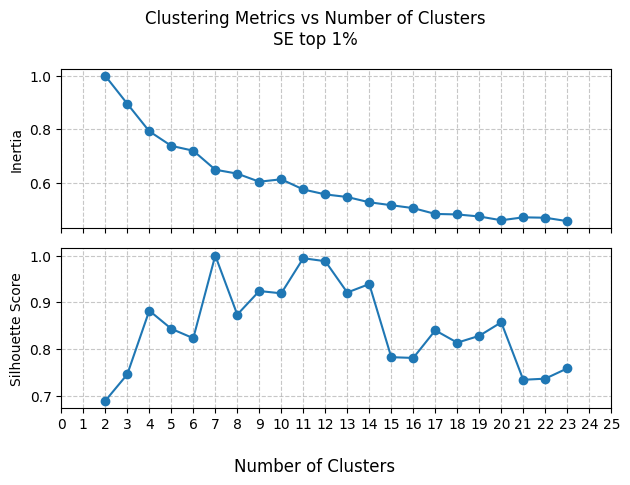

## Train and save

```python
start_time = time.perf_counter()
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(
    xai_dict["norm_unique_weights"]
)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save the model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/kmeans_model.joblib")
```

```python
# # train time: 0.05 seconds
# # ['/home/elom/phd/code/clustering/bin_03/mse/kmeans_7_clusters_150_segments/kmeans_model.joblib']
```

## Save metadata

```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_array].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
```

# Clusters metadata

In [ ]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_weights"],
    print_n_clusters=True,
)

xai_dict["spectra_cluster_dict"] = spectra_cluster_dict
xai_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_unique_weights"],
    print_n_clusters=False,
)

xai_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
xai_dict["centroids"] = centroids

# 0;229
# 1;203
# 2;493
# 3;211
# 4;343
# 5;62
# 6;278

0;229
1;203
2;493
3;211
4;343
5;62
6;278


In [13]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [14]:
for label, centroid in enumerate(xai_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=None,
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

    axs[0].plot(wave_nm, avg_spectrum, color="black", label="Average spectrum")
    axs[0].legend()
    # weights
    axs[1].plot(wave_nm, centroid, color="black", label="Average explanation")
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [23]:
cluster_id = 6

mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = xai_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 6: 278
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [24]:
lines_cols = [
    "h_alpha_flux",
    "h_beta_flux",
    "nii_6548_flux",
    "nii_6584_flux",
    "sii_6717_flux",
    "sii_6731_flux",
    "oii_3726_flux",
    "oii_3729_flux",
    "oiii_4959_flux",
    "oiii_5007_flux",
    "oiii_flux",
]
cluster_meta_df[lines_cols].describe()

,h_alpha_flux,h_beta_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux,oii_3729_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux
count,1.781000e+03,1.785000e+03,1.780000e+03,1.780000e+03,1.750000e+03,1.757000e+03,1.376000e+03,1.388000e+03,1.748000e+03,1.794000e+03,1.794000e+03
mean,1.291045e+07,3.508344e+06,1.532237e+06,4.621580e+06,7.801723e+06,1.705464e+08,7.357351e+06,3.106570e+07,2.131971e+06,2.247704e+06,2.256463e+06
std,5.432590e+08,1.482067e+08,6.463868e+07,1.949651e+08,2.404092e+08,7.093284e+09,1.780755e+08,9.342122e+08,6.624373e+07,9.512768e+07,9.552584e+07
min,2.159138e-01,2.652776e-01,3.730642e-02,1.125248e-01,2.467343e-01,5.699907e-02,6.603864e-02,1.392909e-01,2.608672e-02,4.893990e-02,7.010176e-02
25%,6.398634e+02,1.688366e+02,4.099451e+01,1.236489e+02,1.149903e+02,8.402688e+01,1.258799e+02,1.250825e+02,6.955962e+01,1.854379e+02,1.888304e+02
50%,1.226268e+03,3.200270e+02,9.518348e+01,2.870953e+02,1.897278e+02,1.434133e+02,3.292063e+02,3.128883e+02,1.917229e+02,5.597372e+02,5.639956e+02
75%,2.169182e+03,5.732670e+02,1.910500e+02,5.762510e+02,2.935152e+02,2.257452e+02,6.064615e+02,5.948613e+02,4.641363e+02,1.374444e+03,1.385436e+03
max,2.292654e+10,6.261624e+09,2.727109e+09,8.225589e+09,9.422665e+09,2.973184e+11,6.080421e+09,3.417483e+10,2.468186e+09,4.029195e+09,4.046059e+09


In [25]:
n_nans = cluster_meta_df[lines_cols].isna().sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_nans,n_negatives,n_zeros
0,h_alpha_flux,38,0,0
1,h_beta_flux,34,0,0
2,nii_6548_flux,39,0,0
3,nii_6584_flux,39,0,0
4,sii_6717_flux,69,0,0
5,sii_6731_flux,62,0,0
6,oii_3726_flux,443,0,0
7,oii_3729_flux,431,0,0
8,oiii_4959_flux,71,0,0
9,oiii_5007_flux,25,0,0


In [26]:
# Compute deciles (10th to 90th percentiles) for each column
deciles = np.arange(0.01, 1.01, 0.01)
decile_df = cluster_meta_df[lines_cols].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df

,1th,2th,3th,4th,5th,6th,6th,8th,9th,10th,...,91th,92th,93th,94th,95th,96th,97th,98th,99th,100th
h_alpha_flux,7.186355,13.157498,19.450760,29.612028,40.193440,46.510388,71.043828,116.452440,161.345000,190.381800,...,3599.469400,3846.327400,4064.999000,4276.028800,4563.04700,4923.448400,5616.690600,6328.288600,9.506428e+03,2.292654e+10
h_beta_flux,3.192283,6.065466,8.108324,11.901589,15.416896,19.879935,28.937306,40.588583,47.788423,56.451372,...,946.568296,1008.337440,1056.555080,1105.082080,1176.78460,1291.608760,1408.059160,1583.590440,2.033350e+03,6.261624e+09
nii_6548_flux,1.145356,2.537455,4.865596,6.766799,8.663868,11.029167,12.613179,13.998558,15.304941,16.852802,...,363.588372,380.724308,413.853928,434.724770,471.72010,533.566256,624.372049,768.638014,1.080633e+03,2.727109e+09
nii_6584_flux,3.454659,7.653549,14.675759,20.410229,26.132225,33.266513,38.044253,42.222872,46.163228,50.831954,...,1096.666530,1148.352240,1248.278900,1311.230680,1422.81640,1609.358760,1883.250440,2318.389640,3.259439e+03,8.225589e+09
sii_6717_flux,2.774752,7.488518,11.228410,14.136161,19.954653,25.742632,30.403707,37.923572,44.504381,50.169220,...,453.056918,476.753868,511.149692,536.308660,573.54093,620.136584,694.086372,771.415570,9.281405e+02,9.422665e+09
sii_6731_flux,2.164968,4.558868,7.537006,9.721090,11.669834,17.021521,19.746001,25.662376,29.685566,34.352728,...,360.779160,381.469956,393.693780,414.041916,462.34430,495.044180,553.383856,631.824104,7.371659e+02,2.973184e+11
oii_3726_flux,1.831006,4.729134,7.358460,10.310610,12.539265,16.518030,20.287822,24.176480,33.612927,38.161830,...,1049.099250,1120.276000,1222.667000,1289.078000,1522.91875,1713.551000,3038.595250,51454.200000,1.587074e+06,6.080421e+09
oii_3729_flux,1.464711,3.497100,8.449882,12.436703,15.356618,18.114603,21.671380,25.816385,28.436988,33.214032,...,957.831093,987.324932,1080.277120,1164.553320,1243.50700,1363.625840,1637.961150,2629.529060,3.013391e+06,3.417483e+10
oiii_4959_flux,1.226341,2.545225,3.551934,4.722751,6.321681,7.858709,9.217118,10.928372,13.474827,14.858188,...,926.298568,974.952536,1060.823500,1135.842560,1283.02295,1440.054880,1588.837500,1796.426980,2.323907e+03,2.468186e+09
oiii_5007_flux,2.636009,4.497255,6.803244,9.573504,11.984393,14.025011,16.391192,19.346630,24.520537,29.119260,...,2749.635790,2916.897320,3160.377360,3426.552060,3825.57895,4264.555920,4889.054480,5471.409360,7.176033e+03,4.029195e+09


In [27]:
# replace 0 with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].replace(0, np.nan)
# replace negative fluxes numeric values with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].where(
    cluster_meta_df[lines_cols] >= 0, np.nan
)
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
temp_df = pd.DataFrame({"n_negatives": n_negatives, "n_zeros": n_zeros})
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_negatives,n_zeros
0,h_alpha_flux,0,0
1,h_beta_flux,0,0
2,nii_6548_flux,0,0
3,nii_6584_flux,0,0
4,sii_6717_flux,0,0
5,sii_6731_flux,0,0
6,oii_3726_flux,0,0
7,oii_3729_flux,0,0
8,oiii_4959_flux,0,0
9,oiii_5007_flux,0,0


# Median line ratios

In [28]:
df, ratio_cols = astronomy.compute_emission_line_ratios(cluster_meta_df)
range_n_clusters = range(0, n_clusters)

median_cluster_ratios_df = pd.DataFrame(
    index=range_n_clusters,
    columns=ratio_cols,
)
for cluster_id in range_n_clusters:

    mask = df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        df.loc[mask, "sii_density_ratio"]
    )

median_cluster_ratios_df

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,3.405879,0.241704,1.121202,0.907021,0.627827,0.296001,1.4169
1,3.899575,0.582605,1.422588,1.238518,0.356566,0.370333,1.303926
2,3.883664,0.285493,1.296597,1.35424,0.656916,0.251708,1.321768
3,4.252255,0.595623,1.178214,1.205182,0.400544,0.332161,1.243018
4,3.417836,0.104902,3.384,2.876752,1.438618,0.207551,1.362602
5,4.178478,0.614359,3.068902,4.277589,0.802257,0.318045,1.257286
6,3.358066,0.171281,1.602239,1.146608,0.971925,0.275002,1.391919


In [29]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = df[ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer_decrement,3.603107,3.620602,3.632930,3.647116,3.668969,3.679038,3.692443,3.709852,3.723891,3.741098,3.755085
nii_to_halpha,0.234838,0.239975,0.245432,0.250207,0.254902,0.259614,0.268189,0.277796,0.285090,0.290669,0.298330
oiii_to_hbeta,1.546710,1.601287,1.639899,1.694527,1.730276,1.772498,1.815691,1.847271,1.879173,1.925877,1.985341
oiii_to_oii,1.287236,1.312636,1.345774,1.372980,1.412035,1.458075,1.483448,1.509572,1.528156,1.544221,1.586794
o3n2_index,0.752555,0.765060,0.782803,0.798406,0.814355,0.837632,0.853038,0.866577,0.878822,0.891983,0.909533
sii_to_halpha,0.259456,0.261544,0.264104,0.266410,0.267988,0.269740,0.271213,0.273678,0.275551,0.277863,0.278859
sii_density_ratio,1.334871,1.336922,1.340285,1.344557,1.347186,1.349667,1.352247,1.355150,1.357635,1.359672,1.362148


## Cluster 0 ratios percentiles

In [30]:
cluster_mask = df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.287298,3.383727,3.405879,3.474527,3.584317
nii_to_halpha,0.189816,0.225161,0.241704,0.257330,0.286028
oiii_to_hbeta,0.780642,0.939922,1.121202,1.323703,1.519997
oiii_to_oii,0.735653,0.795965,0.907021,0.948880,1.019327
o3n2_index,0.471208,0.537106,0.627827,0.699028,0.929055
sii_to_halpha,0.280952,0.291045,0.296001,0.304192,0.314734
sii_density_ratio,1.401629,1.412020,1.416900,1.429388,1.443872


## Cluster 1 ratios percentiles

In [31]:
cluster_mask = df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.668743,3.833407,3.899575,4.012044,4.089159
nii_to_halpha,0.493146,0.546843,0.582605,0.641015,0.691358
oiii_to_hbeta,1.085340,1.291200,1.422588,1.615413,1.849417
oiii_to_oii,0.970332,1.038898,1.238518,1.339017,1.483177
o3n2_index,0.244577,0.314531,0.356566,0.462466,0.583592
sii_to_halpha,0.320941,0.344296,0.370333,0.406947,0.437358
sii_density_ratio,1.235690,1.269742,1.303926,1.332128,1.355949


## Cluster 2 percentiles

In [32]:
cluster_mask = df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.742352,3.831876,3.883664,3.960478,4.031044
nii_to_halpha,0.240497,0.257221,0.285493,0.303858,0.327368
oiii_to_hbeta,1.063485,1.182893,1.296597,1.395816,1.542220
oiii_to_oii,1.131801,1.235700,1.354240,1.483577,1.548927
o3n2_index,0.524704,0.575397,0.656916,0.727063,0.791194
sii_to_halpha,0.237558,0.245323,0.251708,0.258464,0.264458
sii_density_ratio,1.293208,1.308758,1.321768,1.336912,1.350726


## Cluster 3 ratios percentiles

In [33]:
cluster_mask = df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,4.052443,4.117211,4.252255,4.358830,4.488764
nii_to_halpha,0.510378,0.540426,0.595623,0.646256,0.684197
oiii_to_hbeta,0.852647,1.021333,1.178214,1.485676,1.893338
oiii_to_oii,0.882286,0.993509,1.205182,1.392831,2.074797
o3n2_index,0.291258,0.351336,0.400544,0.485270,0.573438
sii_to_halpha,0.298074,0.316039,0.332161,0.357929,0.382514
sii_density_ratio,1.190315,1.221487,1.243018,1.258311,1.267997


## Cluster 4 ratios percentiles

In [34]:
cluster_mask = df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.350451,3.386141,3.417836,3.458013,3.521731
nii_to_halpha,0.089080,0.095993,0.104902,0.115185,0.128581
oiii_to_hbeta,3.102826,3.224144,3.384000,3.604576,3.783730
oiii_to_oii,2.476026,2.661757,2.876752,3.189655,3.523269
o3n2_index,1.324315,1.408134,1.438618,1.495249,1.533557
sii_to_halpha,0.192884,0.199419,0.207551,0.217241,0.224637
sii_density_ratio,1.337873,1.354370,1.362602,1.372814,1.383731


## Cluster 5 percentiles

In [35]:
cluster_mask = df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,4.009935,4.157823,4.178478,4.236049,4.268899
nii_to_halpha,0.516163,0.590352,0.614359,0.644389,0.654941
oiii_to_hbeta,2.703902,2.937394,3.068902,3.730995,4.076041
oiii_to_oii,3.349253,3.903348,4.277589,4.837777,4.964027
o3n2_index,0.741378,0.781027,0.802257,0.848446,0.864573
sii_to_halpha,0.304295,0.307722,0.318045,0.343103,0.369840
sii_density_ratio,1.217826,1.237886,1.257286,1.272204,1.295938


## Cluster 6 percentiles

In [36]:
cluster_mask = df["cluster"] == 6
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.269075,3.316644,3.358066,3.402852,3.463225
nii_to_halpha,0.143520,0.155915,0.171281,0.180785,0.192063
oiii_to_hbeta,1.395480,1.462106,1.602239,1.749675,1.877095
oiii_to_oii,0.976342,1.094134,1.146608,1.279954,1.343530
o3n2_index,0.853495,0.910035,0.971925,1.054957,1.110117
sii_to_halpha,0.253656,0.266952,0.275002,0.281215,0.290897
sii_density_ratio,1.370901,1.380546,1.391919,1.402834,1.413018


# Redshift Analysis

In [38]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010613,0.262315,0.066032,0.046336
1,1,0.016175,0.229779,0.097285,0.102753
2,2,0.010093,0.237981,0.069629,0.058084
3,3,0.015511,0.271920,0.087891,0.078368
4,4,0.010132,0.242462,0.051454,0.032587
5,5,0.073334,0.226657,0.117552,0.118039
6,6,0.011578,0.229848,0.048391,0.027801


In [39]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010613,0.262315,0.066032,0.046336,5506.557583,5531.295038,4408.565054,4428.369928,5220.294729,5243.746187,5318.559595,5342.452495
1,1,0.016175,0.229779,0.097285,0.102753,5476.418169,5501.020228,4525.203309,4545.532165,5071.610865,5094.394382,5046.458705,5069.129230
2,2,0.010093,0.237981,0.069629,0.058084,5509.396417,5534.146625,4495.221374,4515.415540,5202.736624,5226.109205,5259.508198,5283.135818
3,3,0.015511,0.271920,0.087891,0.078368,5480.002045,5504.620203,4375.274831,4394.930153,5115.401232,5138.381471,5160.578135,5183.761325
4,4,0.010132,0.242462,0.051454,0.032587,5509.182778,5533.932027,4479.010223,4499.131563,5292.670407,5316.447004,5389.377749,5413.588790
5,5,0.073334,0.226657,0.117552,0.118039,5184.781176,5208.073095,4536.720534,4557.101129,4979.635270,5002.005599,4977.464785,4999.825364
6,6,0.011578,0.229848,0.048391,0.027801,5501.307240,5526.021109,4524.950160,4545.277879,5308.133292,5331.979354,5414.474680,5438.798466
